In [440]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import pickle

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [441]:
with open("../data/02-result/drugs_df.pkl","rb") as f:
    drugs_df =pickle.load(f)
with open("../data/02-result/diseases_df.pkl","rb") as f:
    diseases_df =pickle.load(f)
with open("../data/02-result/trials_df.pkl","rb") as f:
    trials_df =pickle.load(f)
with open("../data/02-result/indications_df.pkl","rb") as f:
    indications_df =pickle.load(f)
with open("../data/01-result/embeddings_df.pkl","rb") as f:
    embeddings_df =pickle.load(f)
with open("../data/01-result/fingerprints_df.pkl","rb") as f:
    fingerprints_df =pickle.load(f)

# Overview

In [442]:
print(f"Drugs:\n    {drugs_df.shape}")
print(f"Diseases:\n    {diseases_df.shape}")
print(f"Trials:\n    {trials_df.shape}")
print(f"Indications:\n    {indications_df.shape}")
print(f"Name embeddings:\n    {embeddings_df.shape}")
print(f"Molecular ingerprints:\n    {fingerprints_df.shape}")

Drugs:
    (2314, 95)
Diseases:
    (197, 58)
Trials:
    (7023, 11)
Indications:
    (7637, 10)
Name embeddings:
    (489939, 5)
Molecular ingerprints:
    (1547, 101)


In [443]:
indications_df["overall_success"].value_counts()

overall_success
False    2184
True     1052
Name: count, dtype: Int64

# Missing values before merging

In [444]:
# drugs_df.isnull().sum().sort_values(ascending=False)
drugs_df = drugs_df.dropna(subset=["targets"])
drugs_df = drugs_df[drugs_df.drug_path_str.str.len()>0]
drugs_df = drugs_df[~drugs_df["biotherapeutic"].astype(bool)]
drugs_df = drugs_df[~drugs_df["withdrawn_flag"]]
drugs_df = drugs_df.drop(columns=["max_phase","helm_notation", "first_approval", "usan_year", "usan_stem_definition",
                                  "standard_inchi_key", "standard_inchi", "canonical_smiles", "full_molformula",
                                  "withdrawn_flag", "black_box_warning", "first_in_class", "molecule_type",
                                  "biotherapeutic", "targets", "drug_pathways", "drug_path_str"])

diseases_df  = diseases_df[diseases_df.disease_path_str.str.len()>0]
diseases_df = diseases_df.drop(columns=["description", "associatedTargets", "phenotypes",
                                         "disease_targets", "disease_pathways", "disease_path_str"])


indications_df = indications_df.dropna(subset=["overall_success"])

In [445]:
print(f"Drugs:\n    {drugs_df.shape}")
print(f"Diseases:\n    {diseases_df.shape}")
print(f"Trials:\n    {trials_df.shape}")
print(f"Indications:\n    {indications_df.shape}")
print(f"Name embeddings:\n    {embeddings_df.shape}")
print(f"Molecular ingerprints:\n    {fingerprints_df.shape}")

Drugs:
    (831, 78)
Diseases:
    (196, 52)
Trials:
    (7023, 11)
Indications:
    (3236, 10)
Name embeddings:
    (489939, 5)
Molecular ingerprints:
    (1547, 101)


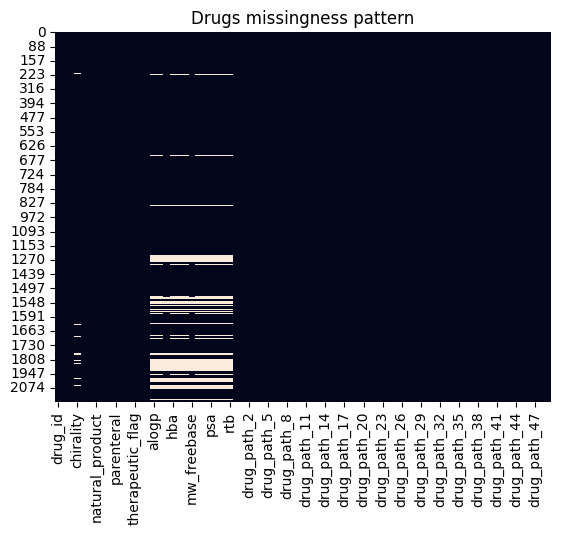

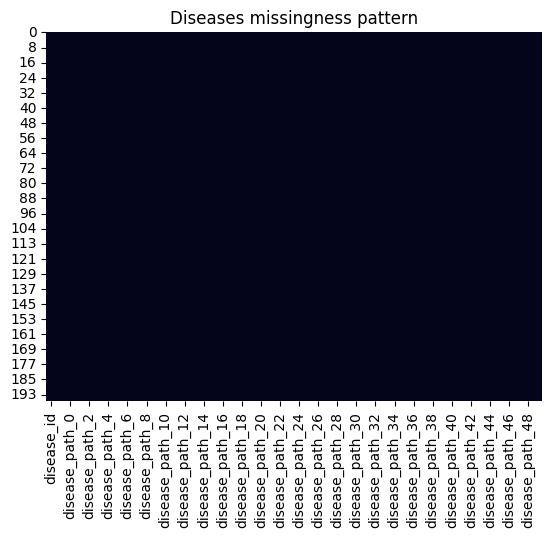

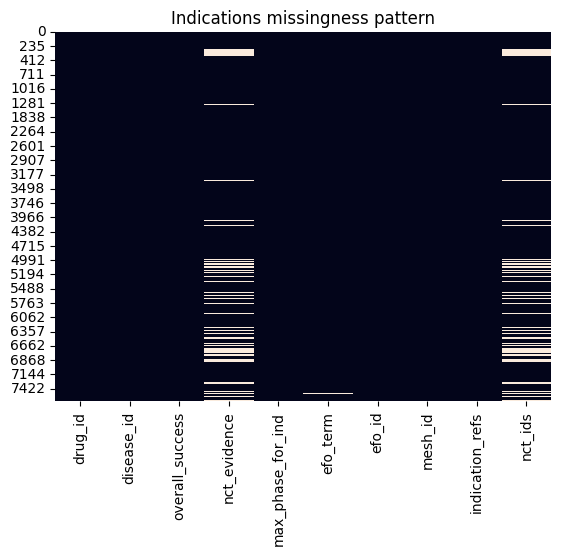

In [446]:
sns.heatmap(drugs_df.isnull(), cbar=False)
plt.title("Drugs missingness pattern")
plt.show()
sns.heatmap(diseases_df.isnull(), cbar=False)
plt.title("Diseases missingness pattern")
plt.show()
sns.heatmap(indications_df.isnull(), cbar=False)
plt.title("Indications missingness pattern")
plt.show()

In [447]:
encoded = pd.get_dummies(drugs_df["chirality"], drop_first=True, dummy_na=True, prefix="chirality_").astype(int) # "achiral" as baseline
drugs_df = drugs_df.drop(columns=["chirality"]).join(encoded)

should_be_num_features = ["dosed_ingredient", "alogp","full_mwt",
             "mw_freebase", "np_likeness_score", "psa", "qed_weighted"]
for col in should_be_num_features:
    drugs_df[col] = pd.to_numeric(drugs_df[col], errors="coerce")

drugs_df["ro3_pass"] = drugs_df["ro3_pass"].str.lower().map({"y": 1, "n":0})

knn_imp = KNNImputer(n_neighbors=5)
num_features = drugs_df.select_dtypes(include=np.number).columns
drugs_df[num_features] = knn_imp.fit_transform(drugs_df[num_features])

# Merge and curate all data

In [448]:
drugs_df = drugs_df.merge(fingerprints_df, on="drug_id")
diseases_df["disease_id"] = diseases_df["disease_id"].str.replace("_",":")
embeddings_df["disease_id"] = embeddings_df["disease_id"].str.replace("_",":")
merged_df = (indications_df[["drug_id", "disease_id", "overall_success"]]
             .merge(drugs_df, on="drug_id")
             .merge(diseases_df, on="disease_id")
             .merge(embeddings_df[["drug_id", "disease_id","name_similarity"]], on =["drug_id", "disease_id"]))

In [449]:
merged_df["disease_name"]

0                                  lymphoma
1                             atopic eczema
2                         allergic rhinitis
3             juvenile idiopathic arthritis
4                      rheumatoid arthritis
                       ...                 
1178                  non-Hodgkins lymphoma
1179                 IGA glomerulonephritis
1180                       multiple myeloma
1181                   Mantle cell lymphoma
1182    autoimmune thrombocytopenic purpura
Name: disease_name, Length: 1183, dtype: object

In [450]:
merged_df = (merged_df[["drug_id","disease_id", "drug_name", "disease_name"]]
             .join(merged_df.select_dtypes(exclude=["object"])))
merged_df = merged_df.rename(columns={"overall_success" : "success"})
merged_df = merged_df.dropna(subset=["success"])
merged_df

,drug_id,disease_id,drug_name,disease_name,success,chemical_probe,dosed_ingredient,inorganic_flag,natural_product,oral,...,disease_path_41,disease_path_42,disease_path_43,disease_path_44,disease_path_45,disease_path_46,disease_path_47,disease_path_48,disease_path_49,name_similarity
0,CHEMBL1467,EFO:0000574,allopurinol,lymphoma,True,0.0,True,0.0,1.0,True,...,0.005239,0.029122,-0.016002,0.079853,0.020295,-0.010043,0.036285,0.005089,0.042312,0.075028
1,CHEMBL514800,EFO:0000274,apremilast,atopic eczema,False,0.0,True,0.0,1.0,True,...,-0.020228,-0.007647,-0.078747,-0.050006,0.065512,-0.011153,0.089468,0.046286,0.097443,0.094691
2,CHEMBL1370,EFO:0005854,budesonide,allergic rhinitis,True,0.0,True,0.0,1.0,True,...,0.048651,-0.002516,0.138820,-0.022043,-0.046279,0.046063,0.005258,0.015994,0.076821,0.249712
3,CHEMBL118,EFO:0002609,celecoxib,juvenile idiopathic arthritis,True,0.0,True,0.0,0.0,True,...,0.034670,-0.013284,0.045651,0.080481,-0.062777,0.025146,-0.013067,0.021488,-0.002977,0.125380
4,CHEMBL118,EFO:0000685,celecoxib,rheumatoid arthritis,True,0.0,True,0.0,0.0,True,...,0.018464,-0.057149,0.012485,-0.016685,0.028022,0.021635,-0.030254,-0.056211,-0.044441,0.221504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1178,CHEMBL4647810,EFO:0005952,elimusertib,non-Hodgkins lymphoma,False,0.0,False,0.0,0.0,False,...,-0.015753,0.026205,0.024638,0.050006,0.034497,0.001371,0.022380,0.002135,0.033640,0.010902
1179,CHEMBL5095401,EFO:0004194,iptacopan hydrochloride,IGA glomerulonephritis,True,0.0,True,0.0,0.0,True,...,-0.033574,0.016008,-0.078126,-0.125055,-0.017658,0.022526,-0.014772,-0.028396,0.001880,0.096047
1180,CHEMBL5315122,EFO:0001378,bortezomib d-mannitol,multiple myeloma,True,0.0,True,0.0,0.0,False,...,-0.003793,0.025983,0.016401,-0.099410,0.044344,-0.024868,-0.031682,0.029144,0.072834,0.373565
1181,CHEMBL5315122,EFO:1001469,bortezomib d-mannitol,Mantle cell lymphoma,True,0.0,True,0.0,0.0,False,...,-0.002496,-0.009736,-0.038252,-0.034740,0.023610,0.010268,0.024163,-0.022099,0.004296,0.106201


In [451]:
print(f"Merged data:\n  {merged_df.shape}")
merged_df["success"].value_counts()

Merged data:
  (1183, 233)


success
False    669
True     514
Name: count, dtype: Int64

# Save results

In [452]:
with open("../data/03-result/drugs_df.pkl","wb") as f:
    pickle.dump(drugs_df,f)
with open("../data/03-result/diseases_df.pkl","wb") as f:
    pickle.dump(diseases_df,f)
with open("../data/03-result/trials_df.pkl","wb") as f:
    pickle.dump(trials_df,f)
with open("../data/03-result/indications_df.pkl","wb") as f:
    pickle.dump(indications_df,f)
with open("../data/03-result/merged_df.pkl","wb") as f:
    pickle.dump(merged_df,f)

# SANDBOX

adapt come from here

In [380]:
# numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
# test= drugs_df.select_dtypes(include=numerics)
# test = test.loc[:,test.apply(lambda col : len(pd.unique(col))>3)]
# sns.pairplot(test, kind="scatter")

# df = final_drugs_df
# # Simple summary
# print(df.isna().sum().sort_values(ascending=False))

# # Visual overview
# plt.figure(figsize=(10, 6))
# msno.matrix(df, sparkline=False)
# plt.title("Missing Values Overview", fontsize=14)
# plt.show()

# # Alternatively, a heatmap to see missing patterns
# msno.heatmap(df, cmap="coolwarm")
# plt.title("Missingness Heatmap On Drug Features")
# plt.show()

# numeric_cols = df.select_dtypes(include=np.number).columns

# plt.figure(figsize=(15, 6))
# df[numeric_cols].boxplot(rot=45)
# plt.title("Boxplot Overview (Potential Outliers)", fontsize=14)
# plt.show()

# for col in numeric_cols:
#     plt.figure(figsize=(6, 4))
#     sns.boxplot(x=df[col], color="lightblue")
#     plt.title(f"Distribution and Outliers: {col}")
#     plt.show()
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt

# corr = df[numeric_cols].corr()

# # Mask lower triangle
# mask = np.triu(np.ones_like(corr, dtype=bool))

# plt.figure(figsize=(10, 8))
# sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", square=True)

# plt.xticks(rotation=45, ha='right')
# plt.yticks(rotation=0)
# plt.title("Correlation Heatmap on Drug Features", fontsize=14)
# plt.tight_layout()
# plt.show()

# import numpy as np
# plt.figure(figsize=(12,6))
# sns.heatmap(df.isna(), cbar=False)  # missing values
# plt.title("Missingness Map")
# plt.show()

# import missingno as msno
# msno.dendrogram(df)
# plt.show()
# plt.figure(figsize=(6,4))
# sns.scatterplot(x='VariableA', y='VariableB', hue=df['VariableB'].isna())
# plt.title("Scatter of VariableA vs VariableB (color shows missingness)")
# plt.show()